# Workshop Notebook: Predicting Critical Heat Flux (CHF) with XGBoost

Welcome to this hands-on machine learning workshop.

In this notebook, we will learn how to:
1. use Google Colab,
2. upload a dataset,
3. understand the idea of **features** and a **target**,
4. train an **XGBoost regression model**,
5. evaluate the model using common metrics,
6. visualize predictions and feature importance,
7. download the results.

---

## What is the scientific goal?

We want to predict **Critical Heat Flux (CHF)** in pool boiling using measurable thermo-physical and surface properties.

In simple words:
- the **inputs** are properties such as pressure, roughness, and thermal conductivity,
- the **output** is the CHF value.

This is a **regression problem**, because the output is a number.

---

## What is XGBoost?

XGBoost is a powerful machine learning algorithm based on many decision trees working together.

Why is it useful?
- it often performs very well on engineering datasets,
- it handles nonlinear relationships,
- it can estimate which input features are most important.

---

## Workshop note

This notebook is written for **beginners**.
So before each code section, you will see a short explanation of:
- what the code is doing,
- why it matters,
- what you should observe in the output.

In [1]:
!pip -q install -U xgboost shap

import warnings
warnings.filterwarnings("ignore")

import os
OUTPUT_DIR = "xgboost_workshop_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete.")
print(f"All workshop outputs will be saved in: {OUTPUT_DIR}")

Setup complete.
All workshop outputs will be saved in: xgboost_workshop_outputs


# Step 1 — Colab basics

Google Colab allows us to run Python code directly in the browser.

A Colab notebook usually has two kinds of cells:
- **Text cells**: explanations, theory, notes
- **Code cells**: Python commands that we run

To run a code cell:
- click inside the cell,
- press the **Run** button on the left, or
- press **Shift + Enter**

In this workshop, we will move step by step from data upload to final model results.

In [2]:
# Import the libraries we will use

import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 — Upload the dataset

Machine learning starts with data.

In this workshop, you will upload your CHF dataset directly from your computer.
This makes the notebook easy to use on any machine, without needing Google Drive.

The code in the next cell will:
- open a file upload window,
- load a CSV or Excel file,
- show the first few rows of the dataset.

---

## What should students notice?

After upload, look for:
- column names,
- units,
- whether the dataset looks properly organized in rows and columns.

In [3]:
# Upload dataset from your computer

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

if filename.lower().endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(filename)
else:
    raise ValueError("Unsupported file format. Please upload a CSV, XLSX, or XLS file.")

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

display(df.head())

Saving Dataset_AI_ML_Workshop.csv to Dataset_AI_ML_Workshop (5).csv
Uploaded file: Dataset_AI_ML_Workshop (5).csv

Dataset loaded successfully.
Dataset shape: 184 rows × 14 columns


,Author,base_material,substrate_material,substrate_thermal_conductivity_W_mK,operational_pressure_kPa,wall_superheat_K,saturated_temperature_C,roughness_Ra,working_fluid,fluid_thermal_conductivity_W_mK,contact_angle_deg,CHF_kW_m2,p_crit_kPa,reduced_pressure
0,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,32.00,56.0,0.081081,FC-72,0.056,15.93,159.9,1380.0,0.073406
1,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,25.90,56.0,0.144144,FC-72,0.056,12.83,164.3,1380.0,0.073406
2,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.17,56.0,0.252252,FC-72,0.056,12.63,191.8,1380.0,0.073406
3,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.51,56.0,0.333333,FC-72,0.056,14.31,220.1,1380.0,0.073406
4,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,22.00,56.0,0.513514,FC-72,0.056,13.77,202.6,1380.0,0.073406


# Step 3 — Standardize the column names

Real datasets are often messy:
- the same quantity may appear under different column names,
- some names may be too long,
- some names may vary across files.

To make the workflow easier, we will rename the important columns to short standard names.

For this notebook, the key columns are:

- `k_s`   → substrate thermal conductivity
- `P`     → pressure
- `T_sat` → saturated temperature
- `R_a`   → roughness
- `k_f`   → fluid thermal conductivity
- `qCHF`  → critical heat flux (target)

---

## Important machine learning idea

The first five columns above are our **features**.  
The last one, `qCHF`, is our **target**.

Features = inputs  
Target = output we want to predict

In [4]:
# Rename important columns to a consistent format

rename_map = {
    "ks": "k_s",
    "kf": "k_f",
    "Tsat": "T_sat",
    "Ra": "R_a",
    "CHF": "qCHF",
    "substrate_thermal_conductivity_W_mK": "k_s",
    "fluid_thermal_conductivity_W_mK": "k_f",
    "operational_pressure_kPa": "P",
    "saturated_temperature_C": "T_sat",
    "roughness_Ra": "R_a",
    "CHF_kW_m2": "qCHF"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_columns = ["k_s", "P", "T_sat", "R_a", "k_f", "qCHF"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"These required columns are missing from the uploaded file: {missing_columns}\n"
        f"Available columns are: {list(df.columns)}"
    )

print("All required columns are present.\n")

overview_df = pd.DataFrame({
    "Column": required_columns,
    "Data type": [str(df[col].dtype) for col in required_columns],
    "Missing values": [int(df[col].isna().sum()) for col in required_columns]
})

display(overview_df)
display(df[required_columns].head())

All required columns are present.



,Column,Data type,Missing values
0,k_s,float64,0
1,P,float64,0
2,T_sat,float64,0
3,R_a,float64,0
4,k_f,float64,0
5,qCHF,float64,0


,k_s,P,T_sat,R_a,k_f,qCHF
0,237.0,101.3,56.0,0.081081,0.056,159.9
1,237.0,101.3,56.0,0.144144,0.056,164.3
2,237.0,101.3,56.0,0.252252,0.056,191.8
3,237.0,101.3,56.0,0.333333,0.056,220.1
4,237.0,101.3,56.0,0.513514,0.056,202.6


# Step 4 — Separate inputs and output

Now we explicitly tell the model:
- which columns are inputs,
- which column is the output to predict.

---

## Teaching point

We are using **five engineering features** to predict **one CHF value**.

This is a common structure in supervised machine learning:

- input variables → features
- known answer → target

In [5]:
# Define features and target

feature_columns = ["k_s", "P", "T_sat", "R_a", "k_f"]
target_column = "qCHF"

X = df[feature_columns].copy()
y = df[target_column].astype(float).copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())

Feature matrix shape: (184, 5)
Target vector shape: (184,)

Feature preview:


,k_s,P,T_sat,R_a,k_f
0,237.0,101.3,56.0,0.081081,0.056
1,237.0,101.3,56.0,0.144144,0.056
2,237.0,101.3,56.0,0.252252,0.056
3,237.0,101.3,56.0,0.333333,0.056
4,237.0,101.3,56.0,0.513514,0.056



Target preview:


,qCHF
0,159.9
1,164.3
2,191.8
3,220.1
4,202.6


# Step 5 — Train/test split

A machine learning model should not be judged on the same data it has already seen.

So we split the data into:
- **training set** → used to teach the model
- **test set** → used to check how well the model works on unseen data

This helps us measure whether the model is actually learning useful patterns.

In this notebook, we use:
- 80% for training
- 20% for testing

In [6]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train/test split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Train/test split completed.
Training samples: 147
Testing samples:  37


# Step 6 — Build the XGBoost model

We are now ready to train the model.

Before training, we include two useful ideas:

### 1. Missing-value handling
Real datasets sometimes contain empty entries.
We use a **median imputer** to fill missing values safely.

### 2. Hyperparameter tuning
XGBoost has settings such as:
- learning rate,
- tree depth,
- number of trees.

Instead of guessing these settings, we let the computer test many combinations using **RandomizedSearchCV**.

### 3. Cross-validation
Cross-validation means the model is trained and checked several times on different portions of the training data.
This gives a more reliable estimate than using only one split.

---

## Important note

For tree-based models such as XGBoost, we usually **do not need feature scaling**.
That is different from some other ML methods.

In [7]:
# Build a beginner-friendly XGBoost pipeline and tune it using randomized search

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",   # efficient on CPU
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", xgb_model)
])

param_distributions = {
    "model__learning_rate": [0.04, 0.08, 0.10, 0.12, 0.15, 0.20],
    "model__n_estimators": [300, 500, 700, 1000, 1400],
    "model__max_depth": [3, 5, 7, 9, 11],
    "model__min_child_weight": [1, 3, 5, 7, 9],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.2, 0.5, 1.0],
    "model__reg_lambda": [0.1, 0.5, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,  # reduced for workshop speed
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_

print("\nBest hyperparameters found:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best hyperparameters found:
model__subsample: 1.0
model__reg_lambda: 1.0
model__reg_alpha: 0.2
model__n_estimators: 1000
model__min_child_weight: 1
model__max_depth: 7
model__learning_rate: 0.1
model__colsample_bytree: 1.0


In [8]:
import xgboost
import sklearn

print("xgboost version:", xgboost.__version__)
print("scikit-learn version:", sklearn.__version__)

xgboost version: 3.2.0
scikit-learn version: 1.4.2


# Step 7 — Evaluate the model

Now the model has been trained.

We will test it on the unseen test data and calculate three common metrics:

### RMSE
Root Mean Squared Error  
Lower is better

### MAE
Mean Absolute Error  
Lower is better

### R²
Coefficient of determination  
Closer to 1 is better

---

## How to interpret these metrics

- **RMSE** tells us the typical size of the prediction error, with larger mistakes penalized more strongly.
- **MAE** tells us the average absolute error.
- **R²** tells us how much of the variation in CHF is explained by the model.

In [9]:
# Predict on the test set and calculate performance metrics

y_pred = best_pipe.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

summary_table = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

print("Model performance on the test set:\n")
display(summary_table)

summary_table.to_csv(os.path.join(OUTPUT_DIR, "xgboost_metrics_summary.csv"), index=False)

Model performance on the test set:



,Metric,Value
0,RMSE,207.203046
1,MAE,139.082689
2,R²,0.925343


# Step 8 — Compare predicted CHF with actual CHF

A useful way to judge the model is to compare:
- the true CHF values,
- the predicted CHF values.

In the parity plot below:
- each point is one test sample,
- the dashed red line is the ideal 1:1 line.

### What do we want?
We want the points to lie close to the red dashed line.

We will also plot the residuals.

Residual = Actual − Predicted

Residual plots help us see whether the model makes errors in a systematic way.

In [10]:
# Helper function to save figures

def save_current_figure(filename):
    full_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {full_path}")

Saved: xgboost_workshop_outputs/xgboost_predicted_vs_actual.jpg


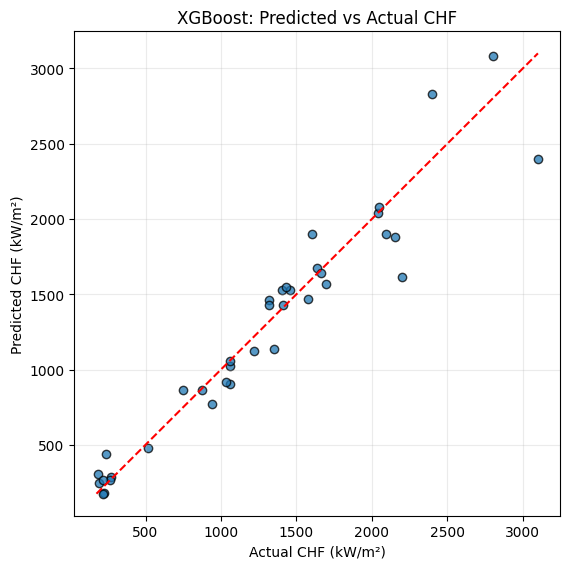

In [11]:
# Parity plot: Actual vs Predicted CHF

plt.figure(figsize=(5.8, 5.8))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Predicted CHF (kW/m²)")
plt.title("XGBoost: Predicted vs Actual CHF")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("xgboost_predicted_vs_actual.jpg")
plt.show()

In [ ]:
# Residual plot

residuals = y_test - y_pred

plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_test, residuals, alpha=0.75, edgecolor="black")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis for XGBoost")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("xgboost_residual_plot.jpg")
plt.show()

# Step 9 — Which features matter most?

One advantage of tree-based models is that they can estimate feature importance.

This does **not** prove physics by itself, but it tells us which inputs the model relied on more strongly.

In the next plot:
- larger importance means the feature had more influence on the model decisions,
- features are ranked from most important to least important.

In [ ]:
# Feature importance plot

trained_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": trained_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature importance table:\n")
display(importance_df)

plt.figure(figsize=(6.5, 4.0))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()

save_current_figure("xgboost_feature_importance.jpg")
plt.show()

# Step 10 — Bonus interpretation with SHAP

This section is optional.

SHAP is a model-interpretation tool that helps us understand:
- which features pushed a prediction upward,
- which features pushed a prediction downward,
- how strongly each feature influenced the final result.

For a beginner workshop, this is a nice advanced topic to show after the main model is complete.

If time is short, this section can be skipped.

In [ ]:
# Optional SHAP analysis

import shap

imputer = best_pipe.named_steps["imputer"]
trained_model = best_pipe.named_steps["model"]

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_columns
)

try:
    explainer = shap.TreeExplainer(trained_model)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values if hasattr(shap_output, "values") else shap_output
except Exception:
    explainer = shap.Explainer(trained_model, X_test_imputed)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values

# SHAP bar plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, plot_type="bar", show=False)
plt.title("SHAP Global Importance")
plt.tight_layout()
save_current_figure("shap_global_importance_bar.jpg")
plt.show()

# SHAP beeswarm plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
save_current_figure("shap_beeswarm.jpg")
plt.show()

# Step 11 — Bonus: visualize hyperparameter sensitivity

This section helps students see that machine learning models are not magic.
Their performance depends on settings such as:
- learning rate,
- maximum tree depth.

The next cell uses the tuning results from the random search and plots how the average CV error changes with these settings.

This is a very useful teaching block because it connects:
- theory,
- optimization,
- model performance.

In [ ]:
# Hyperparameter sensitivity plots using CV results

cv_results = pd.DataFrame(search.cv_results_)

results_df = pd.DataFrame({
    "mean_test_score": cv_results["mean_test_score"],
    "std_test_score": cv_results["std_test_score"],
    "learning_rate": cv_results["param_model__learning_rate"].astype(float),
    "max_depth": cv_results["param_model__max_depth"].astype(int)
})

results_df["mean_RMSE"] = -results_df["mean_test_score"]

lr_group = results_df.groupby("learning_rate", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

depth_group = results_df.groupby("max_depth", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

# Learning rate sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    lr_group["learning_rate"],
    lr_group["mean_RMSE"],
    yerr=lr_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validation RMSE")
plt.title("Learning Rate Sensitivity (XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("learning_rate_sensitivity_xgb.jpg")
plt.show()

# Max depth sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    depth_group["max_depth"],
    depth_group["mean_RMSE"],
    yerr=depth_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validation RMSE")
plt.title("Max Depth Sensitivity (XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("max_depth_sensitivity_xgb.jpg")
plt.show()

# Step 12 — Save and download the final results

A good scientific workflow should save:
- the evaluation metrics,
- the predictions,
- the model settings,
- the figures.

The next cell will:
1. save a test-set prediction table,
2. save the best hyperparameters,
3. zip the output folder,
4. download the zip file to your computer.

In [ ]:
# Save final tables and download everything as a zip file

predictions_df = X_test.copy()
predictions_df["Actual_qCHF"] = y_test.values
predictions_df["Predicted_qCHF"] = y_pred
predictions_df["Residual"] = y_test.values - y_pred

predictions_path = os.path.join(OUTPUT_DIR, "xgboost_test_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)

best_params_clean = {}
for k, v in search.best_params_.items():
    key = k.replace("model__", "")
    if isinstance(v, (np.integer,)):
        best_params_clean[key] = int(v)
    elif isinstance(v, (np.floating,)):
        best_params_clean[key] = float(v)
    else:
        best_params_clean[key] = v

params_path = os.path.join(OUTPUT_DIR, "best_xgboost_params.json")
with open(params_path, "w") as f:
    json.dump(best_params_clean, f, indent=2)

zip_path = shutil.make_archive("xgboost_workshop_results", "zip", OUTPUT_DIR)

print("Saved files:")
print(f"- {predictions_path}")
print(f"- {params_path}")
print(f"- {zip_path}")

files.download(zip_path)

# Final reflection

By this point, you have completed a full beginner-friendly machine learning workflow:

- uploaded a real engineering dataset,
- identified features and target,
- split data into training and testing sets,
- trained an XGBoost regression model,
- evaluated the model,
- visualized predictions,
- interpreted feature importance,
- downloaded the final outputs.

This is a complete example of how machine learning can be used in thermal engineering research.